In [1]:
import torch
import numpy as np
import argparse
import pickle
from collections import defaultdict
from pathlib import Path

from data_processing import load_dataset
from model import HeteroRGCN, HeteroLinkPredictionModel, TransE
from utils import set_config_args
from utils import hetero_src_tgt_khop_in_subgraph


parser = argparse.ArgumentParser(description='Explain link predictor')
'''
Dataset args
'''
parser.add_argument('--dataset_dir', type=str, default='/home/lab/zyd/2023/datasets')
parser.add_argument('--dataset_name', type=str, default='woHERB_KEGG_groundtruth_case')
parser.add_argument('--valid_ratio', type=float, default=0.1) 
parser.add_argument('--test_ratio', type=float, default=0.2)
parser.add_argument('--max_num_samples', type=int, default=-1, 
                    help='maximum number of samples to explain, for fast testing. Use all if -1')

'''
GNN args
'''
parser.add_argument('--emb_dim', type=int, default=64)
parser.add_argument('--hidden_dim', type=int, default=64)
parser.add_argument('--out_dim', type=int, default=64)
# parser.add_argument('--saved_model_dir', type=str, default='saved_models')
parser.add_argument('--saved_model_dir', type=str, default='/home/lab/zyd/2023/code/saved_models')
parser.add_argument('--saved_model_name', type=str, default='')

'''
Link predictor args
'''
parser.add_argument('--src_ntype', type=str, default='drug', help='prediction source node type')
parser.add_argument('--tgt_ntype', type=str, default='disease', help='prediction target node type')
parser.add_argument('--pred_etype', type=str, default='treats', help='prediction edge type')
parser.add_argument('--link_pred_op', type=str, default='dot', choices=['dot', 'cos', 'ele', 'cat'],
                   help='operation passed to dgl.EdgePredictor')

'''
Explanation args
'''
parser.add_argument('--num_hops', type=int, default=5, help='computation graph number of hops') 
# parser.add_argument('--saved_explanation_dir', type=str, default='saved_explanations',
#                     help='directory of saved explanations')
parser.add_argument('--saved_explanation_dir', type=str, default='/home/lab/zyd/2023/code/saved_explanations',
                    help='directory of saved explanations')
parser.add_argument('--eval_explainer_names', nargs='+', default=['our'], 
                    help='name of explainers to evaluate') 
parser.add_argument('--eval_path_hit', default=True, action='store_true', 
                    help='Whether to save the explanation') 
parser.add_argument('--config_path', type=str, default='', help='path of saved configuration args')

args = parser.parse_args('')

if args.config_path:
    args = set_config_args(args, args.config_path, args.dataset_name, 'train_eval')

if 'woHERB' in args.dataset_name:
    args.src_ntype = 'drug'
    args.tgt_ntype = 'disease'
    args.pred_etype = 'treats'
elif 'wHERB' in args.dataset_name:
    args.src_ntype = 'herb'
    args.tgt_ntype = 'disease'
    args.pred_etype = 'has-effects-on'
else:
    raise ValueError('Unknow dataset argument')

if args.link_pred_op in ['cat']:
    pred_kwargs = {"in_feats": args.out_dim, "out_feats": 1}
else:
    pred_kwargs = {}

g, processed_g = load_dataset(args.dataset_dir, args.dataset_name, args.pred_etype, args.valid_ratio, args.test_ratio)
mp_g, train_pos_g, train_neg_g, val_pos_g, val_neg_g, test_pos_g, test_neg_g = [g for g in processed_g]

trans = TransE(mp_g, args.emb_dim)
encoder = HeteroRGCN(mp_g, args.emb_dim, args.hidden_dim, args.out_dim, trans)
model = HeteroLinkPredictionModel(encoder, args.src_ntype, args.tgt_ntype, args.link_pred_op, **pred_kwargs)

if not args.saved_model_name:
    args.saved_model_name = f'our_{args.dataset_name}_model'

# state = torch.load(f'{args.saved_model_dir}/{args.saved_model_name}.pth', map_location='cpu')
state = torch.load(f'/home/lab/zyd/2023/code/saved_models/{args.saved_model_name}.pth', map_location='cpu')
model.load_state_dict(state)     

# test_src_nids, test_tgt_nids = test_pos_g.edges()
query_src_nids, query_tgt_nids = torch.tensor([13788, 11481, 11250]), torch.tensor([5, 165, 165])
# test_ids = range(test_src_nids.shape[0])
test_ids = range(query_src_nids.shape[0])

comp_graphs = defaultdict(list)
comp_g_labels = defaultdict(list)

/home/lab/anaconda3/envs/PaGE-Link/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Pick one example graph

In [2]:
i = 2   # 0: Theophylline  1: Glimepiride 2: Acarbose
# Get the k-hop subgraph
src_nid, tgt_nid = query_src_nids[i], query_tgt_nids[i]
comp_g_src_nid, comp_g_tgt_nid, comp_g, comp_g_feat_nids, comp_g_feat_eids = hetero_src_tgt_khop_in_subgraph(args.src_ntype, 
                                                                                            src_nid,
                                                                                            args.tgt_ntype,
                                                                                            tgt_nid,
                                                                                            mp_g,
                                                                                            args.num_hops)

with torch.no_grad():
    pred = model(comp_g_src_nid, comp_g_tgt_nid, comp_g, comp_g_feat_nids, comp_g_feat_eids).sigmoid().item() > 0.5

if pred:
    src_tgt = ((args.src_ntype, int(src_nid)), (args.tgt_ntype, int(tgt_nid)))
    comp_graphs[src_tgt] = [comp_g_src_nid, comp_g_tgt_nid, comp_g, comp_g_feat_nids]


## Load saved explanation

In [3]:
explainer = args.eval_explainer_names[0]
# saved_explanation_mask = f'{explainer}_{args.saved_model_name}_pred_edge_to_comp_g_edge_mask'
# saved_explanation_mask = f'case_{args.saved_model_name}_pred_edge_to_comp_g_edge_mask'
saved_explanation_mask = '/home/lab/zyd/result/paths/mask_pathway_20'
saved_file = Path.cwd().joinpath(args.saved_explanation_dir, saved_explanation_mask)
with open(saved_file, "rb") as f:
    explanation_mask = pickle.load(f)

## Extract paths and construct the explanation graph to plot

In [4]:
import dgl
def get_exp_g(g, paths, src_ntype, src_nid, tgt_ntype, tgt_nid):
    path_eids = {}
    for path in paths:
        for edge in path:
            etype, u, v = edge
            eids = comp_g.edge_ids(u=u, v=v, etype=etype)
            # path_eids[etype] = eids
            try:
                path_eids[etype].append(eids)
            except:
                path_eids[etype] = []
                path_eids[etype].append(eids)                

    exp_g = g
    for etype in g.canonical_etypes:
        # hard_edge_mask = hard_edge_mask_dict[etype]
        remove_eids = g.edges(form='eid', etype=etype)
        if etype in path_eids:
            # remove_eids = remove_eids[remove_eids != path_eids[etype]]
            for eid in path_eids[etype]:
                remove_eids = remove_eids[remove_eids != eid]
        exp_g = dgl.remove_edges(exp_g, remove_eids, etype=etype) # creates a new graph

    exp_g = dgl.compact_graphs(exp_g, always_preserve={src_ntype : src_nid, tgt_ntype : tgt_nid })

    # Get src and tgt nid in the explanation graph
    # Note: the input graph should have node data dgl.NID
    exp_g_src_nid_in_g = exp_g.ndata[dgl.NID][src_ntype]
    exp_g_src_nid = (exp_g_src_nid_in_g == src_nid).nonzero().view(-1)
    exp_g_tgt_nid_in_g = exp_g.ndata[dgl.NID][tgt_ntype]
    exp_g_tgt_nid = (exp_g_tgt_nid_in_g == tgt_nid).nonzero().view(-1)

    return exp_g, exp_g_src_nid, exp_g_tgt_nid   

comp_g_edge_mask_dict = explanation_mask[src_tgt]

from explainer import PaGELink
pagelink = PaGELink(model)
paths = pagelink.get_paths(comp_g_src_nid, comp_g_tgt_nid, comp_g, comp_g_edge_mask_dict, num_paths=10, max_path_length=5)

exp_g, exp_g_src_nid, exp_g_tgt_nid = get_exp_g(comp_g, 
                                                paths,
                                                args.src_ntype,
                                                comp_g_src_nid,
                                                args.tgt_ntype,
                                                comp_g_tgt_nid)

Graph(num_nodes={'disease': 1, 'drug': 1335, 'pathway': 187, 'target1': 1138, 'target2': 331},
      num_edges={('drug', 'aims-at', 'target1'): 2351, ('drug', 'treats', 'disease'): 0, ('pathway', 'includes', 'target2'): 631, ('target1', 'included-by', 'pathway'): 6679, ('target2', 'causes', 'disease'): 331},
      metagraph=[('drug', 'target1', 'aims-at'), ('drug', 'disease', 'treats'), ('target1', 'pathway', 'included-by'), ('pathway', 'target2', 'includes'), ('target2', 'disease', 'causes')])


## Set plot arguments and plot

In [5]:
from utils import plot_hetero_graph

if 'woHERB' in args.dataset_name:
    ntypes_to_nshapes = {'drug':'p', 'disease':'D', 'pathway':'s', 'target':'o', 'target1':'o', 'target2':'o'}
    ntypes_to_nlayers = {'drug':0, 'disease':4, 'target':1, 'target1':1, 'pathway':2, 'target2':3}
    ntypes_to_ncolors = {'drug':'#e77c8e', 'disease':'#9F79C1', 'pathway':'#63bbd0', 'target':'#f2ce2b', 'target1':'#f2ce2b', 'target2':'#f2ce2b'}
elif 'wHERB' in args.dataset_name:
    args.src_ntype = 'herb'
    args.tgt_ntype = 'disease'
    args.pred_etype = 'has-effects-on'

# if 'synthetic' in args.dataset_name:
#     ntypes_to_nshapes = {'user':'p', 'item':'o', 'attr':'s'}
#     ntypes_to_nlayers = {'user': 0, 'item': 1, 'attr': 2, }
#     ntypes_to_ncolors = {'user':'#FFBFB5', 'item':'#C5E0B4', 'attr':'#8FAADC'}
    
# elif 'citation' in args.dataset_name:
#     ntypes_to_nshapes = {'author':'p', 'paper':'o', 'ref':'^', 'fos':'s'}
#     ntypes_to_nlayers = {'author': 0, 'paper': 1, 'fos': 2, 'ref': 3}
#     ntypes_to_ncolors = {'author':'#FFBFB5', 'paper':'#C5E0B4', 'fos':'#8FAADC', 'ref':'#FFD966'}
    
edge_kwargs = {"edge_color" : '#96c24e',
               "style" : '-',
               "width" : 2,
               "arrows" : True,
               "arrowstyle" : '-|>',
               "arrowsize" : 30}

selected_edge_kwargs = {"edge_color" : '#de1c31',
                        "style" : '--',
                        "width" : 1,
                        "arrows" : False}
selected_edge_dict = {(args.src_ntype, args.pred_etype, args.tgt_ntype) : (exp_g_src_nid, exp_g_tgt_nid)}

In [6]:
import pickle
import io
import inspect

def read_dict(file_path):
    f_read = io.open(file_path, 'rb')
    dict = pickle.load(f_read)
    f_read.close()
    return dict

def retrieve_name(var):
    callers_local_vars = inspect.currentframe().f_back.f_locals.items()
    return [var_name for var_name, var_val in callers_local_vars if var_val is var]

def retrieve_dict(dic):
    new_dic = {v:k for k,v in dic.items()}
    return new_dic

node_dict = {}
node_dict['disease'] = retrieve_dict(read_dict('/home/lab/zyd/2023/data/graph/nodes/disease_dict.pkl'))
node_dict['target'] = retrieve_dict(read_dict('/home/lab/zyd/2023/data/graph/nodes/target_dict.pkl'))
node_dict['pathway'] = retrieve_dict(read_dict('/home/lab/zyd/2023/data/graph/nodes/pathway_dict.pkl'))
node_dict['drug'] = retrieve_dict(read_dict('/home/lab/zyd/2023/data/graph/nodes/drug_dict.pkl'))
node_dict['target1'] = retrieve_dict(read_dict('/home/lab/zyd/2023/data/graph/nodes/target_dict.pkl'))
node_dict['target2'] = retrieve_dict(read_dict('/home/lab/zyd/2023/data/graph/nodes/target_dict.pkl'))


for k,v in node_dict['disease'].items():
    node_dict['disease'][k] = v.split(' [')[0].strip()
    if k == 165:
        node_dict['disease'][k] = 'T2DM'

for k,v in node_dict['pathway'].items():
    node_dict['pathway'][k] = v.split(':')[1].strip()

Graph(num_nodes={'disease': 1, 'drug': 1, 'pathway': 2, 'target1': 2, 'target2': 4},
      num_edges={('drug', 'aims-at', 'target1'): 2, ('drug', 'treats', 'disease'): 0, ('pathway', 'includes', 'target2'): 7, ('target1', 'included-by', 'pathway'): 4, ('target2', 'causes', 'disease'): 4},
      metagraph=[('drug', 'target1', 'aims-at'), ('drug', 'disease', 'treats'), ('target1', 'pathway', 'included-by'), ('pathway', 'target2', 'includes'), ('target2', 'disease', 'causes')])


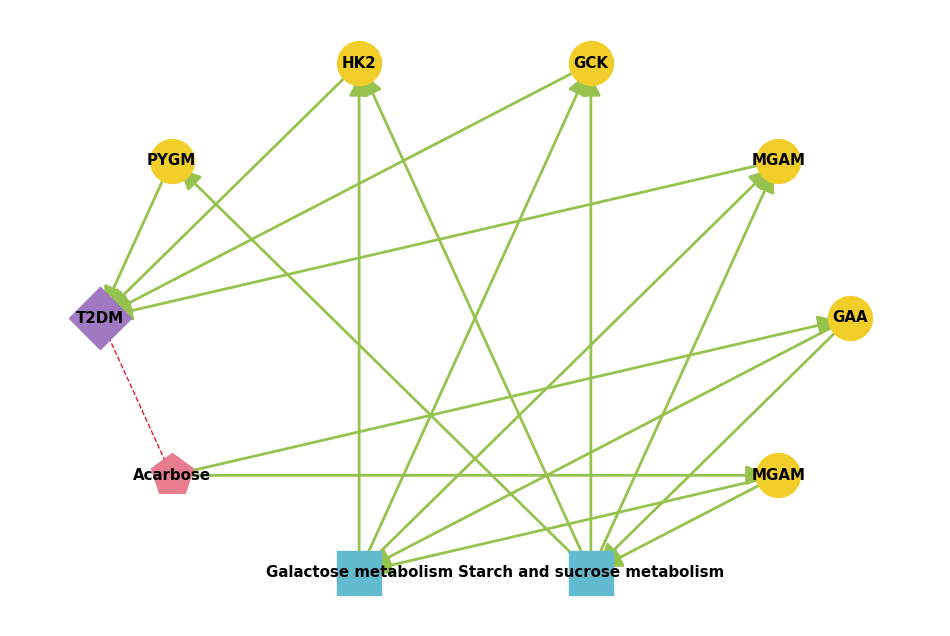

In [7]:
nx_graph = plot_hetero_graph(exp_g,                             
                             ntypes_to_nshapes,
                             ntypes_to_ncolors,
                             ntypes_to_nlayers,
                            #  layout='spring',
                             layout='shell',
                            #  layout='spectral',
                             label= 'nx_id',
                             etype_label=None,
                             edge_kwargs=edge_kwargs,
                             selected_edge_kwargs=selected_edge_kwargs,
                             selected_edge_dict=selected_edge_dict,
                             node_name_dict=node_dict,
                            #  label_offset=True,
                             figsize=(12, 8))

# Processing batch

In [8]:
# import os

# # 0: Theophylline  1: Glimepiride 2: Acarbose
# case_list = ['Theophylline', 'Glimepiride', 'Acarbose']
# case = case_list[i]
# save_path = f'/home/lab/zyd/result/nxplot_{case}_pathway/' 
# # save_path = f'/home/lab/zyd/result/nxplot_{case}/' 
# if not os.path.exists(save_path):
#     os.makedirs(save_path)    

# topk = [1,2,3,5,10] #,15,20]
# for k in topk:
#     paths = pagelink.get_paths(comp_g_src_nid, comp_g_tgt_nid, comp_g, comp_g_edge_mask_dict, num_paths=k, max_path_length=5)
#     exp_g, exp_g_src_nid, exp_g_tgt_nid = get_exp_g(comp_g, 
#                                                     paths,
#                                                     args.src_ntype,
#                                                     comp_g_src_nid,
#                                                     args.tgt_ntype,
#                                                     comp_g_tgt_nid)
#     if k==1:
#         layout = 'spectral' #'spring'
#     else:
#         layout= 'spectral'    #'multipartite'
    
#     fig_name = save_path + f'top{k}.png'
    
#     nx_graph = plot_hetero_graph(exp_g,
#                              ntypes_to_nshapes,
#                              ntypes_to_ncolors,
#                              ntypes_to_nlayers,
#                              layout = layout,
#                              label= 'nx_id',
#                              edge_kwargs=edge_kwargs,
#                              selected_edge_kwargs=selected_edge_kwargs,
#                              selected_edge_dict=selected_edge_dict,
#                              fig_name = fig_name,
#                              node_name_dict=node_dict,
#                              etype_label=None,
#                              figsize=(10, 8))